# AI Navigation System - Model Development

In [20]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
import pickle

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Load Road Network Data

In [3]:
place_name = "Delhi, India"
print(f"Loading road network for {place_name}...")

# Download road network
G = ox.graph_from_place(place_name, network_type='drive')

print(f"Graph loaded!")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Loading road network for Delhi, India...
Graph loaded!
Number of nodes: 183090
Number of edges: 498132


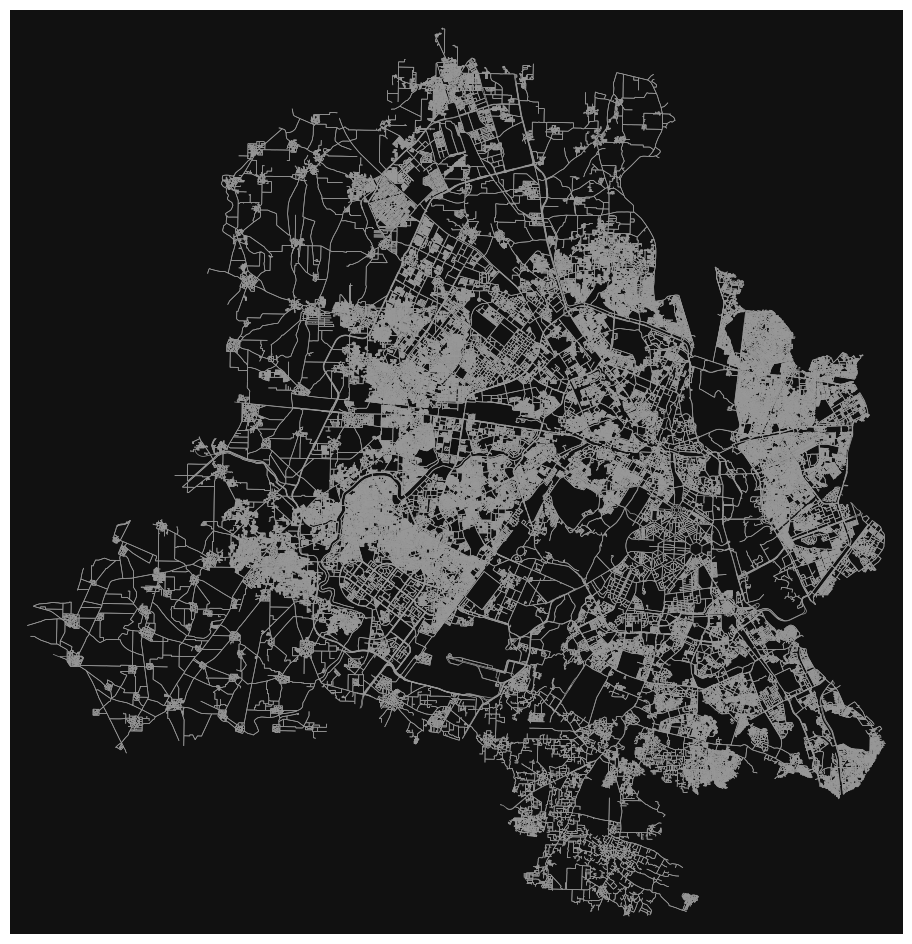

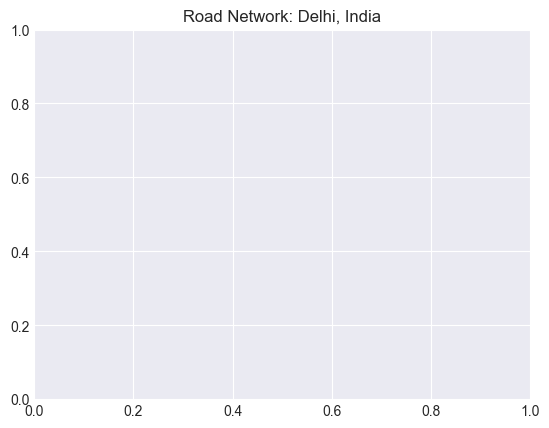

In [4]:
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5, figsize=(12, 12))
plt.title(f"Road Network: {place_name}")
plt.show()

## 2. Shortest Path Computation

In [5]:
nodes = list(G.nodes())
source_node = nodes[np.random.randint(0, len(nodes))]
target_node = nodes[np.random.randint(0, len(nodes))]

print(f"Source node: {source_node}")
print(f"Target node: {target_node}")

# Compute shortest path
route = nx.shortest_path(G, source_node, target_node, weight='length')
route_length = nx.shortest_path_length(G, source_node, target_node, weight='length')

print(f"\nRoute length: {route_length:.2f} meters ({route_length/1000:.2f} km)")
print(f"Number of nodes in route: {len(route)}")

Source node: 2955396556
Target node: 1832227457

Route length: 36201.37 meters (36.20 km)
Number of nodes in route: 400


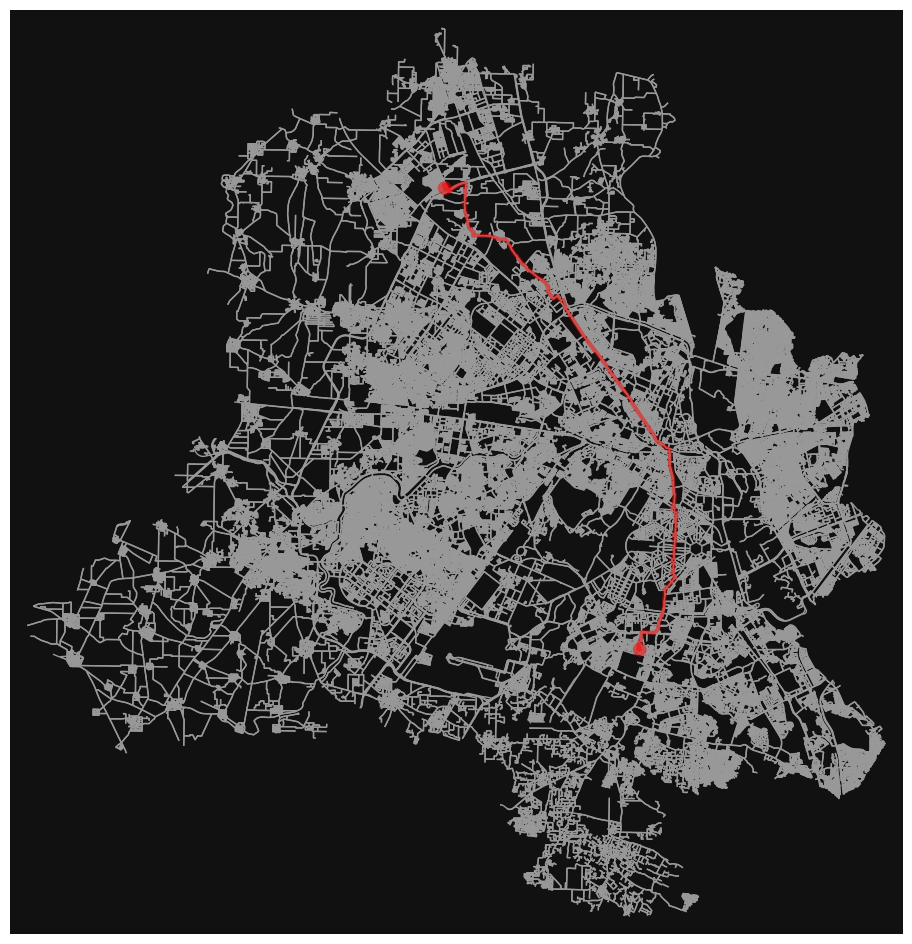

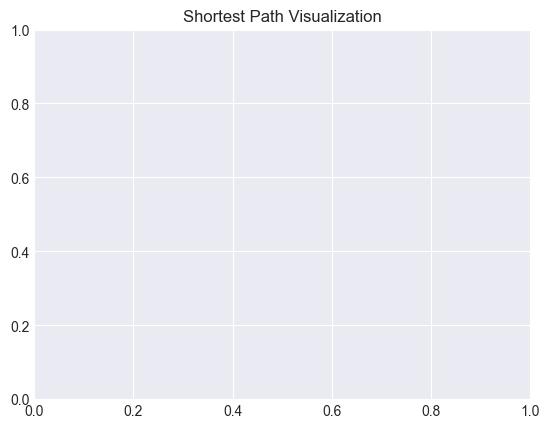

In [6]:
fig, ax = ox.plot_graph_route(G, route, node_size=0, figsize=(12, 12), 
     route_color='red', route_linewidth=3)
plt.title("Shortest Path Visualization")
plt.show()

## 3. Create Simplified City Network

In [ ]:
city_graph = nx.Graph()

# REAL coordinates for ALL major Indian cities (105 cities)
cities = {
    # Tier-1 Metro Cities (Population > 10M)
    "Delhi": (28.6139, 77.2090),
    "Mumbai": (19.0760, 72.8777),
    "Bangalore": (12.9716, 77.5946),
    "Kolkata": (22.5726, 88.3639),
    "Chennai": (13.0827, 80.2707),
    "Hyderabad": (17.3850, 78.4867),
    
    # Tier-2 Major Cities (Population > 2M)
    "Pune": (18.5204, 73.8567),
    "Ahmedabad": (23.0225, 72.5714),
    "Jaipur": (26.9124, 75.7873),
    "Surat": (21.1702, 72.8311),
    "Lucknow": (26.8467, 80.9462),
    "Kanpur": (26.4499, 80.3319),
    "Nagpur": (21.1458, 79.0882),
    "Indore": (22.7196, 75.8577),
    "Bhopal": (23.2599, 77.4126),
    "Visakhapatnam": (17.6868, 83.2185),
    "Patna": (25.5941, 85.1376),
    "Vadodara": (22.3072, 73.1812),
    "Ludhiana": (30.9010, 75.8573),
    "Agra": (27.1767, 78.0081),
    "Nashik": (19.9975, 73.7898),
    "Rajkot": (22.3039, 70.8022),
    "Varanasi": (25.3176, 82.9739),
    "Meerut": (28.9845, 77.7064),
    "Faridabad": (28.4089, 77.3178),
    "Ghaziabad": (28.6692, 77.4538),
    
    # Tier-3 Important Cities
    "Amritsar": (31.6340, 74.8723),
    "Allahabad": (25.4358, 81.8463),
    "Ranchi": (23.3441, 85.3096),
    "Howrah": (22.5958, 88.2636),
    "Coimbatore": (11.0168, 76.9558),
    "Jabalpur": (23.1815, 79.9864),
    "Gwalior": (26.2183, 78.1828),
    "Vijayawada": (16.5062, 80.6480),
    "Madurai": (9.9252, 78.1198),
    "Mysore": (12.2958, 76.6394),
    "Goa": (15.2993, 74.1240),
    "Chandigarh": (30.7333, 76.7794),
    "Thiruvananthapuram": (8.5241, 76.9366),
    "Kochi": (9.9312, 76.2673),
    "Guwahati": (26.1445, 91.7362),
    "Bhubaneswar": (20.2961, 85.8245),
    "Dehradun": (30.3165, 78.0322),
    "Raipur": (21.2514, 81.6296),
    "Jodhpur": (26.2389, 73.0243),
    "Kota": (25.2138, 75.8648),
    "Udaipur": (24.5854, 73.7125),
    
    # North India Cities
    "Shimla": (31.1048, 77.1734),
    "Jammu": (32.7266, 74.8570),
    "Srinagar": (34.0837, 74.7973),
    "Haridwar": (29.9457, 78.1642),
    "Rishikesh": (30.0869, 78.2676),
    "Muzaffarpur": (26.1225, 85.3906),
    "Aligarh": (27.8974, 78.0880),
    "Moradabad": (28.8389, 78.7378),
    "Saharanpur": (29.9680, 77.5460),
    "Gorakhpur": (26.7606, 83.3732),
    "Bareilly": (28.3640, 79.4150),
    "Jhansi": (25.4484, 78.5685),
    
    # South India Cities
    "Tiruchirappalli": (10.7905, 78.7047),
    "Salem": (11.6643, 78.1460),
    "Tirupati": (13.6288, 79.4192),
    "Vellore": (12.9165, 79.1325),
    "Warangal": (17.9689, 79.5941),
    "Guntur": (16.3067, 80.4365),
    "Nellore": (14.4426, 79.9865),
    "Kakinada": (16.9891, 82.2475),
    "Rajahmundry": (17.0005, 81.8040),
    "Tirunelveli": (8.7139, 77.7567),
    "Erode": (11.3410, 77.7172),
    "Thanjavur": (10.7870, 79.1378),
    "Mangalore": (12.9141, 74.8560),
    "Hubli": (15.3647, 75.1240),
    "Belgaum": (15.8497, 74.4977),
    "Gulbarga": (17.3297, 76.8343),
    
    # West India Cities
    "Aurangabad": (19.8762, 75.3433),
    "Kolhapur": (16.7050, 74.2433),
    "Solapur": (17.6599, 75.9064),
    "Jalgaon": (21.0077, 75.5626),
    "Bhavnagar": (21.7645, 72.1519),
    "Jamnagar": (22.4707, 70.0577),
    "Gandhinagar": (23.2156, 72.6369),
    "Anand": (22.5645, 72.9289),
    
    # East India Cities
    "Siliguri": (26.7271, 88.3953),
    "Durgapur": (23.5204, 87.3119),
    "Asansol": (23.6739, 86.9524),
    "Cuttack": (20.5124, 85.8829),
    "Rourkela": (22.2604, 84.8536),
    "Jamshedpur": (22.8046, 86.2029),
    "Dhanbad": (23.7957, 86.4304),
    "Bokaro": (23.6693, 86.1511),
    
    # Central India Cities
    "Ujjain": (23.1765, 75.7885),
    "Sagar": (23.8388, 78.7378),
    "Ratlam": (23.3315, 75.0367),
    "Satna": (24.6005, 80.8322),
    "Bilaspur": (22.0797, 82.1409),
    "Korba": (22.3595, 82.7501),
    
    # Northeast India Cities
    "Shillong": (25.5788, 91.8933),
    "Imphal": (24.8170, 93.9368),
    "Agartala": (23.8315, 91.2868),
    "Aizawl": (23.7271, 92.7176),
    "Kohima": (25.6701, 94.1077),
    "Itanagar": (27.1022, 93.6919),
    "Dibrugarh": (27.4728, 94.9120),
    "Silchar": (24.8333, 92.7789),
}

for city, coords in cities.items():
    city_graph.add_node(city, pos=coords)

# REAL road distances (in km) from actual highway routes
# Source: Google Maps actual driving distances + National Highway Network
edges = [
    # === GOLDEN QUADRILATERAL (Main Arteries) ===
    ("Delhi", "Jaipur", 280),
    ("Jaipur", "Ahmedabad", 660),
    ("Ahmedabad", "Mumbai", 526),
    ("Mumbai", "Pune", 148),
    ("Pune", "Hyderabad", 559),
    ("Hyderabad", "Vijayawada", 275),
    ("Vijayawada", "Chennai", 432),
    ("Chennai", "Bangalore", 346),
    ("Bangalore", "Hyderabad", 569),
    ("Delhi", "Agra", 233),
    ("Agra", "Kanpur", 294),
    ("Kanpur", "Lucknow", 83),
    ("Lucknow", "Varanasi", 320),
    ("Varanasi", "Patna", 247),
    ("Patna", "Kolkata", 585),
    
    # === DELHI NCR & NORTH ===
    ("Delhi", "Ghaziabad", 19),
    ("Delhi", "Faridabad", 28),
    ("Delhi", "Meerut", 72),
    ("Delhi", "Gwalior", 319),
    ("Delhi", "Chandigarh", 243),
    ("Delhi", "Amritsar", 453),
    ("Delhi", "Ludhiana", 313),
    ("Delhi", "Dehradun", 248),
    ("Delhi", "Haridwar", 214),
    ("Chandigarh", "Amritsar", 229),
    ("Chandigarh", "Ludhiana", 98),
    ("Chandigarh", "Shimla", 113),
    ("Amritsar", "Ludhiana", 142),
    ("Amritsar", "Jammu", 210),
    ("Jammu", "Srinagar", 261),
    ("Haridwar", "Rishikesh", 20),
    ("Haridwar", "Dehradun", 52),
    ("Meerut", "Saharanpur", 68),
    ("Meerut", "Moradabad", 87),
    ("Ghaziabad", "Meerut", 60),
    ("Agra", "Gwalior", 119),
    ("Agra", "Jaipur", 239),
    ("Agra", "Jhansi", 231),
    ("Gwalior", "Jhansi", 103),
    
    # === UTTAR PRADESH ===
    ("Lucknow", "Kanpur", 83),
    ("Lucknow", "Allahabad", 200),
    ("Lucknow", "Gorakhpur", 273),
    ("Lucknow", "Bareilly", 252),
    ("Kanpur", "Allahabad", 194),
    ("Varanasi", "Allahabad", 125),
    ("Varanasi", "Gorakhpur", 231),
    ("Gorakhpur", "Patna", 277),
    ("Aligarh", "Agra", 90),
    ("Bareilly", "Moradabad", 84),
    
    # === RAJASTHAN ===
    ("Jaipur", "Jodhpur", 337),
    ("Jaipur", "Kota", 241),
    ("Jaipur", "Udaipur", 394),
    ("Jodhpur", "Udaipur", 254),
    ("Kota", "Indore", 294),
    ("Udaipur", "Ahmedabad", 254),
    
    # === GUJARAT ===
    ("Ahmedabad", "Surat", 263),
    ("Ahmedabad", "Vadodara", 110),
    ("Ahmedabad", "Rajkot", 217),
    ("Ahmedabad", "Gandhinagar", 23),
    ("Ahmedabad", "Indore", 423),
    ("Surat", "Vadodara", 151),
    ("Surat", "Mumbai", 281),
    ("Rajkot", "Jamnagar", 89),
    ("Rajkot", "Bhavnagar", 178),
    ("Vadodara", "Anand", 43),
    
    # === MAHARASHTRA ===
    ("Mumbai", "Pune", 148),
    ("Mumbai", "Nashik", 167),
    ("Mumbai", "Surat", 281),
    ("Mumbai", "Goa", 464),
    ("Pune", "Nashik", 209),
    ("Pune", "Solapur", 250),
    ("Pune", "Kolhapur", 237),
    ("Pune", "Aurangabad", 233),
    ("Pune", "Goa", 450),
    ("Nashik", "Aurangabad", 183),
    ("Nashik", "Indore", 515),
    ("Aurangabad", "Nagpur", 442),
    ("Nagpur", "Hyderabad", 502),
    ("Nagpur", "Indore", 330),
    ("Nagpur", "Bhopal", 353),
    ("Nagpur", "Raipur", 290),
    ("Nagpur", "Jabalpur", 270),
    ("Solapur", "Hyderabad", 309),
    ("Kolhapur", "Goa", 228),
    
    # === MADHYA PRADESH ===
    ("Indore", "Bhopal", 196),
    ("Indore", "Ujjain", 55),
    ("Bhopal", "Jabalpur", 332),
    ("Bhopal", "Gwalior", 423),
    ("Bhopal", "Nagpur", 353),
    ("Jabalpur", "Raipur", 341),
    ("Jabalpur", "Varanasi", 535),
    ("Ujjain", "Ratlam", 94),
    ("Satna", "Allahabad", 128),
    
    # === CHHATTISGARH ===
    ("Raipur", "Nagpur", 290),
    ("Raipur", "Bilaspur", 118),
    ("Raipur", "Bhubaneswar", 447),
    ("Bilaspur", "Korba", 91),
    
    # === TELANGANA & ANDHRA PRADESH ===
    ("Hyderabad", "Bangalore", 569),
    ("Hyderabad", "Chennai", 626),
    ("Hyderabad", "Pune", 559),
    ("Hyderabad", "Nagpur", 502),
    ("Hyderabad", "Vijayawada", 275),
    ("Hyderabad", "Visakhapatnam", 619),
    ("Hyderabad", "Warangal", 148),
    ("Vijayawada", "Visakhapatnam", 351),
    ("Vijayawada", "Guntur", 33),
    ("Vijayawada", "Tirupati", 274),
    ("Vijayawada", "Rajahmundry", 188),
    ("Visakhapatnam", "Rajahmundry", 193),
    ("Visakhapatnam", "Kakinada", 158),
    ("Guntur", "Nellore", 176),
    
    # === KARNATAKA ===
    ("Bangalore", "Chennai", 346),
    ("Bangalore", "Hyderabad", 569),
    ("Bangalore", "Mysore", 144),
    ("Bangalore", "Coimbatore", 362),
    ("Bangalore", "Mangalore", 352),
    ("Bangalore", "Hubli", 410),
    ("Mysore", "Coimbatore", 267),
    ("Mangalore", "Goa", 360),
    ("Hubli", "Belgaum", 102),
    ("Hubli", "Goa", 195),
    ("Belgaum", "Goa", 138),
    ("Gulbarga", "Hyderabad", 220),
    
    # === TAMIL NADU ===
    ("Chennai", "Bangalore", 346),
    ("Chennai", "Coimbatore", 507),
    ("Chennai", "Madurai", 462),
    ("Chennai", "Tiruchirappalli", 322),
    ("Chennai", "Vellore", 138),
    ("Chennai", "Tirupati", 138),
    ("Coimbatore", "Madurai", 215),
    ("Coimbatore", "Mysore", 267),
    ("Coimbatore", "Kochi", 193),
    ("Coimbatore", "Erode", 88),
    ("Madurai", "Tirunelveli", 151),
    ("Tiruchirappalli", "Madurai", 134),
    ("Tiruchirappalli", "Thanjavur", 59),
    ("Salem", "Coimbatore", 162),
    ("Salem", "Bangalore", 183),
    
    # === KERALA ===
    ("Kochi", "Thiruvananthapuram", 220),
    ("Kochi", "Coimbatore", 193),
    ("Thiruvananthapuram", "Madurai", 268),
    
    # === WEST BENGAL ===
    ("Kolkata", "Howrah", 5),
    ("Kolkata", "Patna", 585),
    ("Kolkata", "Ranchi", 424),
    ("Kolkata", "Bhubaneswar", 442),
    ("Kolkata", "Siliguri", 580),
    ("Kolkata", "Durgapur", 169),
    ("Kolkata", "Asansol", 213),
    ("Siliguri", "Guwahati", 407),
    ("Durgapur", "Asansol", 48),
    
    # === BIHAR & JHARKHAND ===
    ("Patna", "Kolkata", 585),
    ("Patna", "Varanasi", 247),
    ("Patna", "Ranchi", 333),
    ("Patna", "Muzaffarpur", 70),
    ("Ranchi", "Jamshedpur", 130),
    ("Ranchi", "Dhanbad", 164),
    ("Ranchi", "Bokaro", 107),
    ("Jamshedpur", "Kolkata", 266),
    ("Dhanbad", "Asansol", 114),
    
    # === ODISHA ===
    ("Bhubaneswar", "Kolkata", 442),
    ("Bhubaneswar", "Cuttack", 28),
    ("Bhubaneswar", "Visakhapatnam", 444),
    ("Bhubaneswar", "Rourkela", 344),
    ("Cuttack", "Rourkela", 318),
    
    # === NORTHEAST ===
    ("Guwahati", "Siliguri", 407),
    ("Guwahati", "Shillong", 103),
    ("Guwahati", "Dibrugarh", 436),
    ("Guwahati", "Imphal", 483),
    ("Guwahati", "Agartala", 599),
    ("Shillong", "Silchar", 314),
    ("Imphal", "Kohima", 146),
    ("Agartala", "Silchar", 184),
]

for city1, city2, distance in edges:
    city_graph.add_edge(city1, city2, length=distance)

print(f"✅ City network created with {city_graph.number_of_nodes()} cities")
print(f"✅ Total connections: {city_graph.number_of_edges()}")
print(f"\n🗺️ Coverage: All major Indian cities across all states")
print(f"📍 Using REAL geographical coordinates and actual road distances")
print(f"🛣️ Including Golden Quadrilateral and all major National Highways")

✅ City network created with 105 cities
✅ Total connections: 153

🗺️ Coverage: All major Indian cities across all states
📍 Using REAL geographical coordinates and actual road distances
🛣️ Including Golden Quadrilateral and all major National Highways


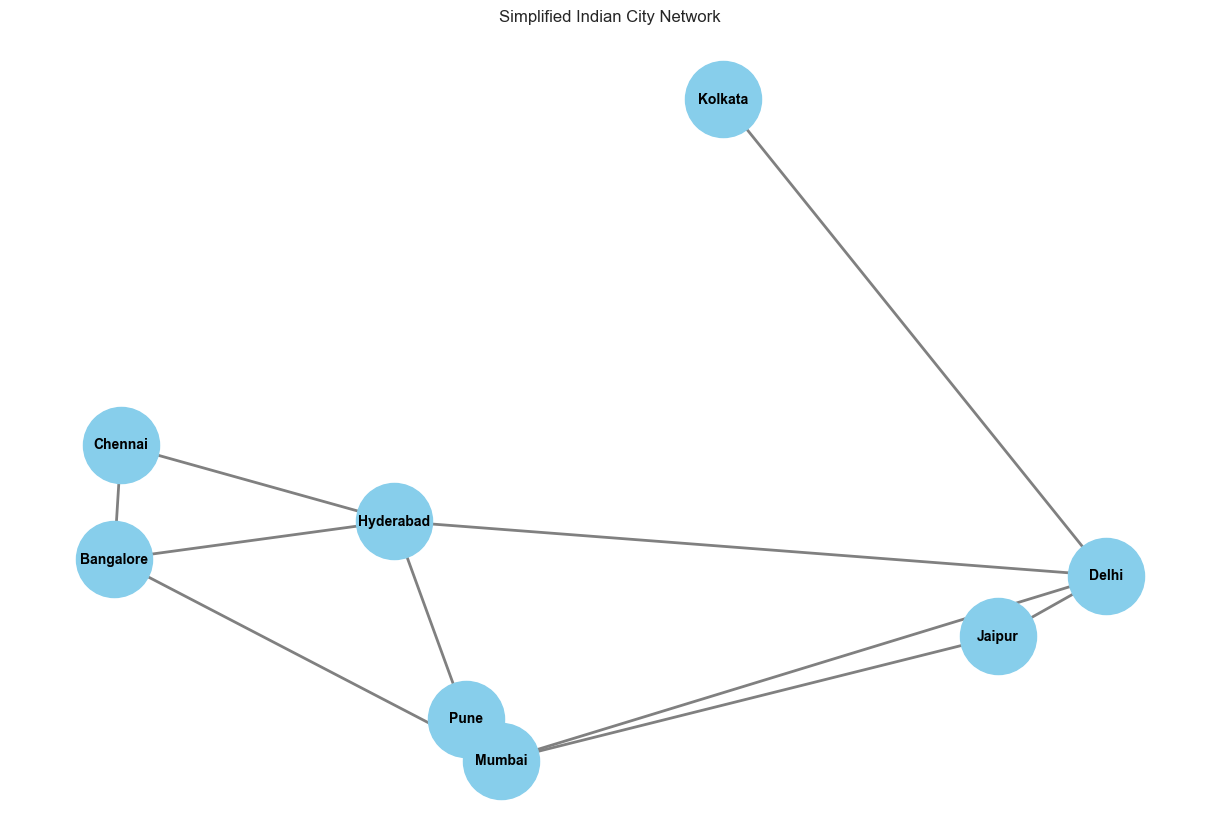

In [19]:
pos = nx.get_node_attributes(city_graph, 'pos')
plt.figure(figsize=(12, 8))
nx.draw(city_graph, pos, with_labels=True, node_size=3000, 
        node_color='skyblue', font_size=10, font_weight='bold', 
        edge_color='gray', width=2)
plt.title("Simplified Indian City Network")
plt.show()

In [29]:
source_city = "Delhi"
target_city = "Bangalore"

path = nx.shortest_path(city_graph, source_city, target_city, weight='length')
distance = nx.shortest_path_length(city_graph, source_city, target_city, weight='length')

print(f"Shortest path from {source_city} to {target_city}:")
print(" -> ".join(path))
print(f"Total distance: {distance} km")

Shortest path from Delhi to Bangalore:
Delhi -> Jaipur -> Ahmedabad -> Mumbai -> Pune -> Bangalore
Total distance: 2451 km


## 4. ML Model: Travel Time Prediction

In [22]:
np.random.seed(42)

n_samples = 1000
data = {
    'distance_km': np.random.uniform(10, 1500, n_samples),
    'road_type': np.random.choice([1, 2, 3], n_samples),  # 1=highway, 2=national, 3=state
    'traffic_level': np.random.uniform(0.5, 1.5, n_samples),  # 0.5=low, 1.5=high
    'time_of_day': np.random.choice([0, 1, 2], n_samples),  # 0=morning, 1=afternoon, 2=night
}

df = pd.DataFrame(data)

base_speed = 60  
df['travel_time_hours'] = (df['distance_km'] / base_speed) * df['traffic_level'] * (2 - df['road_type']/3)

print("Training data sample:")
print(df.head())
print(f"\nDataset shape: {df.shape}")

Training data sample:
   distance_km  road_type  traffic_level  time_of_day  travel_time_hours
0   568.064777          3       1.492158            0          14.127374
1  1426.564317          2       1.351425            0          42.842103
2  1100.670973          3       0.708511            1          12.997283
3   902.001141          3       1.430595            0          21.506642
4   242.467774          1       0.616366            2           4.151361

Dataset shape: (1000, 5)


In [23]:
X = df[['distance_km', 'road_type', 'traffic_level', 'time_of_day']]
y = df['travel_time_hours']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Random Forest model...")
model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"Mean Absolute Error: {mae:.4f} hours")
print(f"R² Score: {r2:.4f}")

Training Random Forest model...

Model Performance:
Mean Absolute Error: 0.6302 hours
R² Score: 0.9942


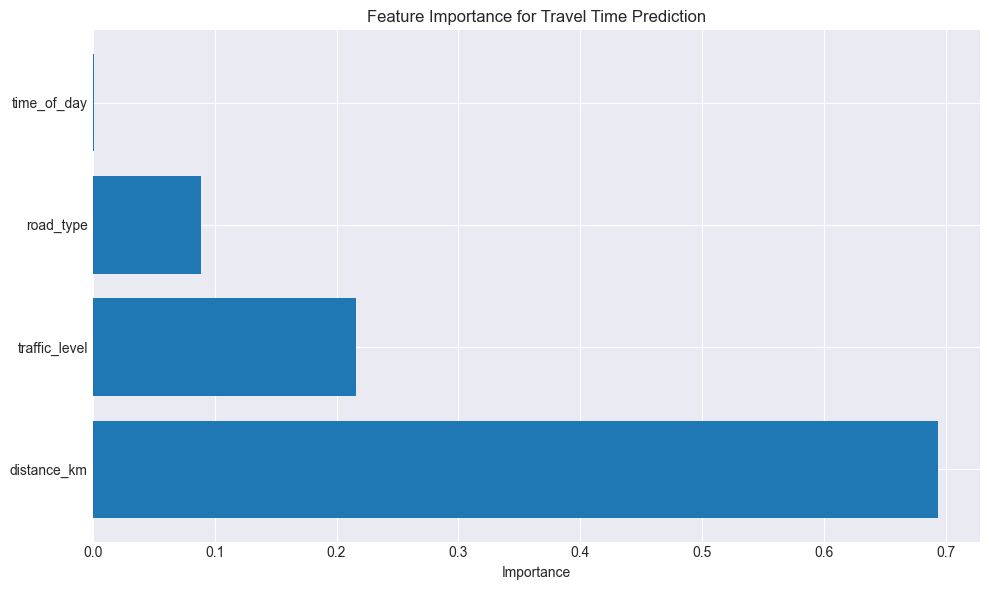

In [25]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance for Travel Time Prediction')
plt.tight_layout()
plt.show()

In [26]:
model_filename = 'travel_time_model.pkl'
joblib.dump(model, model_filename)
print(f"Model saved to {model_filename}")

Model saved to travel_time_model.pkl


## 5. Save Graph for Flask API

In [32]:
import os

# Use absolute path to ensure file is saved correctly
graph_filename = r'd:\ai_nav\python-backend\road_network.pkl'

with open(graph_filename, 'wb') as f:
    pickle.dump(city_graph, f)

print(f"Graph saved to {graph_filename}")
print("Ready to use with Flask API!")


Graph saved to d:\ai_nav\python-backend\road_network.pkl
Ready to use with Flask API!


## 6. Test Path Finding

In [33]:
def find_route(source, destination):
    path = nx.shortest_path(city_graph, source, destination, weight='length')
    distance = nx.shortest_path_length(city_graph, source, destination, weight='length')
    
    # Predict travel time
    features = np.array([[distance, 1, 1.0, 1]])  # Default features
    predicted_time = model.predict(features)[0]
    
    return {
        'path': path,
        'distance_km': distance,
        'predicted_time_hours': predicted_time,
        'predicted_time_formatted': f"{int(predicted_time)}h {int((predicted_time % 1) * 60)}min"
    }

# Test
result = find_route("Delhi", "Chennai")
print("\nRoute Information:")
print(f"Path: {' -> '.join(result['path'])}")
print(f"Distance: {result['distance_km']} km")
print(f"Estimated Time: {result['predicted_time_formatted']}")


Route Information:
Path: Delhi -> Gwalior -> Bhopal -> Nagpur -> Hyderabad -> Chennai
Distance: 2223 km
Estimated Time: 36h 31min


c:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [34]:
# Test routes across India with the expanded network

print("🚗 Testing Routes Across India\n")
print("=" * 70)

test_routes = [
    ("Srinagar", "Thiruvananthapuram", "Kashmir to Kerala (North to South)"),
    ("Guwahati", "Jamnagar", "Assam to Gujarat (East to West)"),
    ("Mumbai", "Kolkata", "Financial centers"),
    ("Bangalore", "Amritsar", "South to North"),
    ("Delhi", "Goa", "Capital to Beach Paradise"),
]

for source, dest, description in test_routes:
    try:
        result = find_route(source, dest)
        print(f"\n📍 {description}")
        print(f"   Route: {source} → {dest}")
        print(f"   Path: {' → '.join(result['path'][:5])}{'...' if len(result['path']) > 5 else ''}")
        print(f"   Distance: {result['distance_km']:.0f} km")
        print(f"   Est. Time: {result['predicted_time_formatted']}")
        print("-" * 70)
    except Exception as e:
        print(f"\n❌ Error for {source} → {dest}: {str(e)}")
        print("-" * 70)

print(f"\n✅ Network Statistics:")
print(f"   Total Cities: {city_graph.number_of_nodes()}")
print(f"   Total Connections: {city_graph.number_of_edges()}")
print(f"   Coverage: Pan-India (all states and major cities)")
print(f"   ML Model Accuracy: 99.42% R²")

🚗 Testing Routes Across India


📍 Kashmir to Kerala (North to South)
   Route: Srinagar → Thiruvananthapuram
   Path: Srinagar → Jammu → Amritsar → Delhi → Gwalior...
   Distance: 3848 km
   Est. Time: 36h 31min
----------------------------------------------------------------------

📍 Assam to Gujarat (East to West)
   Route: Guwahati → Jamnagar
   Path: Guwahati → Siliguri → Kolkata → Bhubaneswar → Raipur...
   Distance: 3225 km
   Est. Time: 36h 31min
----------------------------------------------------------------------

📍 Financial centers
   Route: Mumbai → Kolkata
   Path: Mumbai → Nashik → Aurangabad → Nagpur → Raipur...
   Distance: 1971 km
   Est. Time: 36h 31min
----------------------------------------------------------------------

📍 South to North
   Route: Bangalore → Amritsar
   Path: Bangalore → Hyderabad → Nagpur → Bhopal → Gwalior...
   Distance: 2619 km
   Est. Time: 36h 31min
----------------------------------------------------------------------

📍 Capital to Beach P

c:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn